In [18]:
!pip install scikit-image
!pip install opencv-python
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import cv2
import matplotlib.pyplot as plt

def read_image(imagem):
    image = cv2.imread(imagem)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

def show_image(imagem):
    plt.imshow(imagem)
    plt.axis('off')
    plt.show


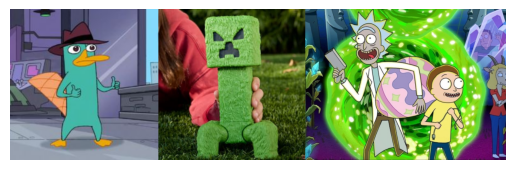

In [36]:
avatares = read_image('avatares.png')
show_image(avatares)

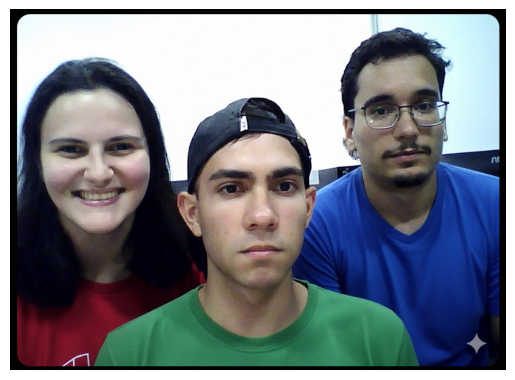

In [5]:
foto_grupo = read_image('foto-grupo.jpeg')
show_image(foto_grupo)

In [60]:
import numpy as np

DELAY_CAPTION = 1500
DELAY_BLUR = 100
MAX_KERNEL_LENGTH = 31
 
src = None
dst = None
window_name = 'Smoothing Demo'

def display_dst(delay):
    cv2.imshow(window_name, dst)
    c = cv2.waitKey(delay)
    if c >= 0 : return -1
    return 0

def display_caption(caption):
    global dst
    dst = np.zeros(src.shape, src.dtype)
    rows, cols, _ch = src.shape
    cv2.putText(dst, caption,
                (int(cols / 4), int(rows / 2)),
                cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255))
    
    return display_dst(DELAY_CAPTION)

def mediana(imagem):
    global src
    src = imagem
    
    if display_caption('Median Blur') != 0:
        return 0

    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.medianBlur(src,k)
        nome_arquivo = f'borramento_mediano{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


def gaussian(imagem):
    global src
    src = imagem

    # Aplicando o borramento gausiiano
    if display_caption('Gaussian Blur') != 0:
        return 0

    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.GaussianBlur(src, (k,k), 0)  # tupla (k,k) e sigmaX=0
        nome_arquivo = f'borramento_gaussiano{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


def bilateral(imagem):
    global src
    src = imagem

    # aplicando filtro bilateral
    if display_caption('Bilateral Blur') != 0:
        return 0
 
    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.bilateralFilter(src, k, k*2, k/2)  
        nome_arquivo = f'borramento_bilateral{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst

def media(imagem):
    global src
    src = imagem

    # aplicando filtro de media
    if display_caption('Homogeneous Blur') != 0:
        return 0
 
    
    kernels = [3, 5, 11, 29]
    resultados = {}

    for k in kernels:
        dst = cv2.blur(src, (k,k))
        nome_arquivo = f'borramento_media{k}x{k}.jpg'
        cv2.imwrite(nome_arquivo, dst)
        resultados[k] = dst
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return dst


imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


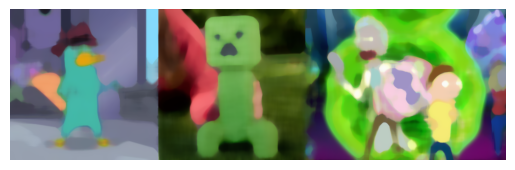

In [53]:
imagem_suavizada = mediana(avatares)
show_image(imagem_suavizada)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


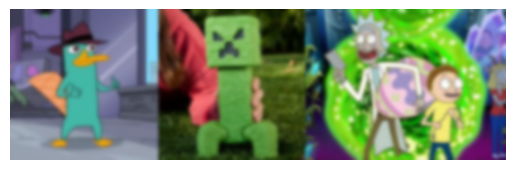

In [49]:
gaussiano = gaussian(avatares)
show_image(gaussiano)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


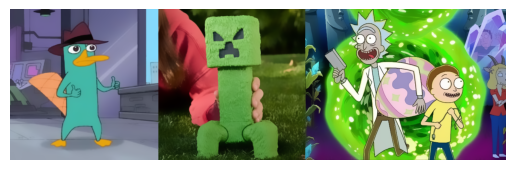

In [51]:
bilateral = bilateral(avatares)
show_image(bilateral)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


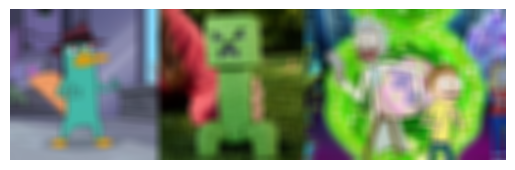

In [61]:
media = media(avatares)
show_image(media)

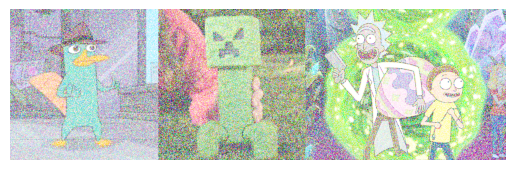

In [64]:
def add_gaussian_noise(imagem, mean=0, std=25):
    noise = np.random.normal(mean,std,imagem.shape).astype(np.uint8)
    noisy_image = cv2.add(imagem, noise)
    return noisy_image

img_ruido = add_gaussian_noise(avatares)
show_image(img_ruido)

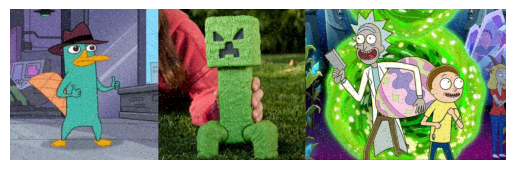

In [65]:
def add_salt_and_pepper_noise(image, noise_ratio=0.02):
    noisy_image = image.copy()
    h, w, c = noisy_image.shape
    noisy_pixels = int(h * w * noise_ratio)
 
    for _ in range(noisy_pixels):
        row, col = np.random.randint(0, h), np.random.randint(0, w)
        if np.random.rand() < 0.5:
            noisy_image[row, col] = [0, 0, 0] 
        else:
            noisy_image[row, col] = [255, 255, 255]
 
    return noisy_image

img_sal_pimenta = add_salt_and_pepper_noise(avatares)
show_image(img_sal_pimenta)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


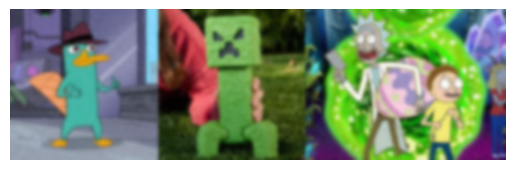

In [69]:
gaussiano_recuperacao = gaussian(img_sal_pimenta)
show_image(gaussiano_recuperacao)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


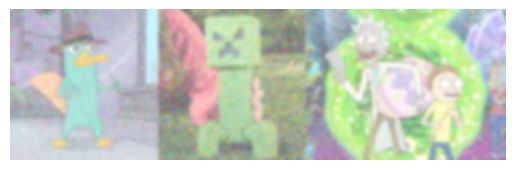

In [68]:
gaussiano = gaussian(img_ruido)
show_image(gaussiano)

In [ ]:
def similaridade_imagens(I1, I2):
    s1 = cv.absdiff(I1, I2) #|I1 - I2|
    s1 = np.float32(s1)     # cannot make a square on 8 bits
    s1 = s1 * s1            # |I1 - I2|^2
    sse = s1.sum()          # sum elements per channel
    if sse <= 1e-10:        # sum channels
        return 360          # For very small SSE, return 360 to cap PSNR (theoretical value is infinity)
    else:
        shape = I1.shape
        mse = 1.0 * sse / (shape[0] * shape[1] * shape[2])
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr


